# Deep Learning Assignment 4: CNNs for Face Identification 

We will perform face identification using a subset of the [Labeled Faces in the Wild (LFW) dataset](http://vis-www.cs.umass.edu/lfw/). Face identification is a multi-class calssification problem where we have training/testing images for a set of subjects (classes). In 2014, researchers were able to surpass human accuracy in facial identification tasks using CNN models (along with advanced deep learning techniques)! 

We will observe the performance of a traditional face identification method, [Eigenfaces](https://en.wikipedia.org/wiki/Eigenface). We will then build a CNN model in order to surpass the accuracy of the traditional Eigenfaces technique. In the process, we will learn about the great power of CNNs!

### Requirements

1. Python 3.6
2. `pip install numpy`
3. `pip install sklearn`
4. `pip install matplotlib`
5. `pip install tensorflow==2.0.0`


### Rubric

1. Complete the sample CNN as specified by the comments (2 pts.)
2. Build three CNN models which surpass the traditional Eigenface method test accuracy. In each model use different architectures and optimizers. Points will be not be awarded if models architectures are not sufficiently different (3 pts.)
3. Build a fourth CNN model which achieves >70% test accuracy (3 pts.)
4. Display a correctly identified image and a training image corresponding to the correct training subject (1 pts.)
5. Display a incorrectly identified image and a training image corresponding to the correct training subject (1 pts.)


In [1]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score
from sklearn.datasets import fetch_lfw_people
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Concatenate, Input, Dense, Activation, Conv2D, MaxPool2D, AveragePooling2D, Flatten, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.optimizers import SGD, RMSprop, Adam
import matplotlib.pyplot as plt

np.random.seed(42)
tf.random.set_seed(42)

Let's start by downloading and setting up a subset of the aligned and segmented version of the LFW dataset. We will only get subjects with at least 20 corresponding images. We will also get the grayscale versions of the images. This may take a few minutes . . .

In [124]:
data_x, data_y = fetch_lfw_people(min_faces_per_person=20, color=False, return_X_y=True)
# normalize pixel values to [0,1]
data_x = data_x / 255.

The downloaded `data_x` will be the flattened vector representation of the images. 

We will reshape the vector respresentations back into the original grayscale images and store the images back in `data_x`.

In [125]:
num_subjects = np.unique(data_y).shape[0]
print("Number of subjects: {}".format(np.unique(data_y).shape[0]))
print("Number of images: {}\n".format(data_y.shape[0]))

# image_x will contain the original grayscale images 
data_x = np.copy(data_x.reshape((data_x.shape[0], 62, 47, 1)))

print("data_x shape: {}".format(data_x.shape))
print("data_y shape: {}".format(data_y.shape))

Number of subjects: 62
Number of images: 3023

data_x shape: (3023, 62, 47, 1)
data_y shape: (3023,)


As we can see, the dataset is made up of `3023` images of `62` subjects (or classes). 

Each image is a `62x47x1`-dimensional matrix containing 8-bit (0-255) grayscale pixel values.

Let's visualize a few of the grayscale images.

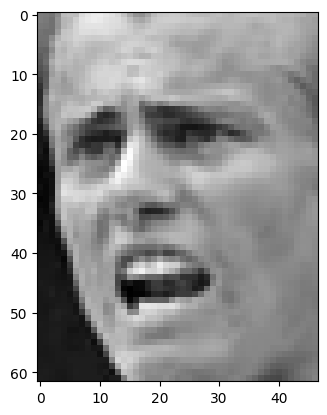

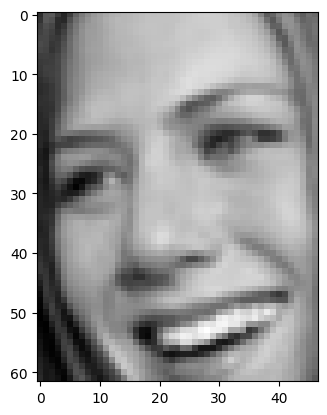

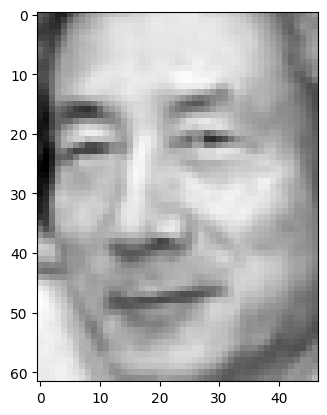

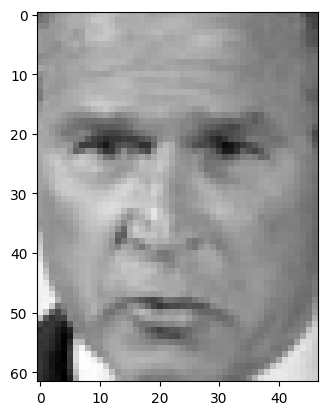

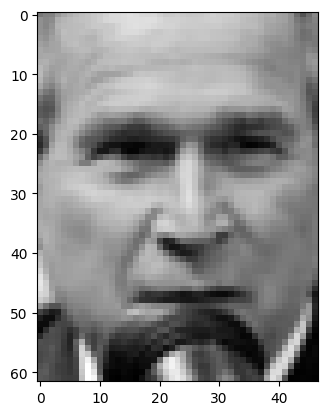

In [126]:
np.random.seed(42)
for i in range(5):
    rnd_idx = np.random.choice(data_y.shape[0])
    rnd_img = data_x[rnd_idx]
    plt.figure()
    plt.imshow(rnd_img[:, :, 0], cmap="gray")

Now, let's split the dataset into train and test sets so we can perform face identification!

We will perform a `90/10` stratified split. This means that `90%` of each subject's images are placed in the train set, while the remaining `10%` of each subject's images are placed into the test set. 

In [119]:
train_x, test_x, train_y, test_y = train_test_split(data_x, data_y, test_size=0.1, random_state=42)

print("train_x shape: {}".format(train_x.shape))
print("train_y shape: {}\n".format(train_y.shape))

print("test_x shape: {}".format(test_x.shape))
print("test_y shape: {}".format(test_y.shape))

train_x shape: (1159, 62, 47, 1)
train_y shape: (1159,)

test_x shape: (129, 62, 47, 1)
test_y shape: (129,)


### Eigenfaces Overview

Eigenfaces is a face identification technique proposed in 1987. It was a very popular algorithm through the 1990's and is still used today as a baseline algorithm when gauging the performance of proposed face identification techniques. Eigenfaces is used to extract features from facial images. Such facial features are more useful in identification tasks than the corresponding oringinal images. The facial features can then be used for identification by being classified by a multi-class classifier, such a logistic regression model. 

### Eigenfaces Details

Eigenfaces is a Principcal Componet Analysis (PCA)-based dimensionality-reduction technique. Eigenfaces deals with the flattened vector representations of the face images. 

We give the vector representation of the training images as input to the algorithm. The output of the algoirthm is a set of Eigenfaces (vectors) which we can use to project vector representations of images into a lower-dimensional space which (hopefully) encode important facial features. 

Since the lower-dimensional space captures important facial features, Eigenfaces is used as a feature extraction technique. Given a facial image, we can reshape the image into a vector. Using the Eigenfaces, we reduce the dimensionality of the original vector into a vector which is more useful in identifying its corresponging subject. Therefore, we will use the Eigenfaces to extract facial features. Then, we will use a simple logistic regression classifier to classify the resulting facial features.

Let's start by flattening the training facial images. Then we will continue by computing the Eigenfaces which capture `95%` of the variance of the original dataset.

In [6]:
# flatten images 
train_vector_x = train_x.reshape((train_x.shape[0], train_x.shape[1]*train_x.shape[2])) 
test_vector_x = test_x.reshape((test_x.shape[0], test_x.shape[1]*test_x.shape[2])) 

# retrieve eigenfaces
pca = PCA(n_components=0.95, random_state=42)
pca.fit(train_vector_x)
eigenfaces = pca.components_

print("Training vectors shape: {}".format(train_vector_x.shape))
print("Eigenfaces shape: {}".format(eigenfaces.shape))

Training vectors shape: (2720, 2914)
Eigenfaces shape: (202, 2914)


As we see, if we flatten the training images to gather their vector representations, we recieve `2720` vectors of size `2914`. We also see that we have found `173` Eigenfaces vectors of size `2914`.

If we reshape the set of Eigenfaces to the shape of the original images, they reveal intesting ghost faces (i.e. "Eigenfaces").

Let's view the first `10` Eigenfaces.

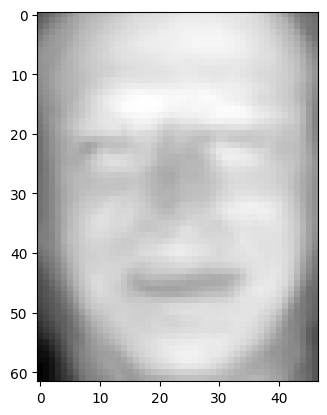

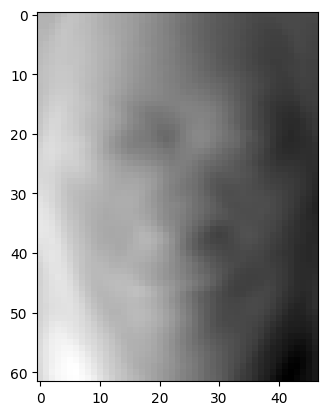

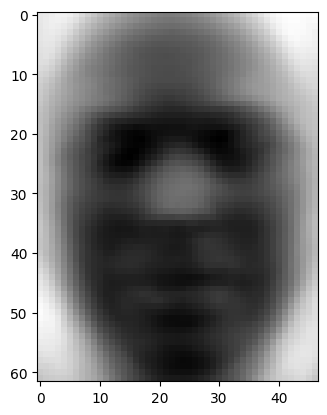

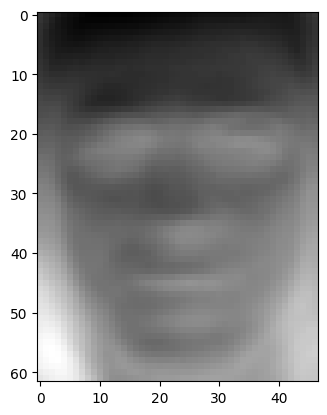

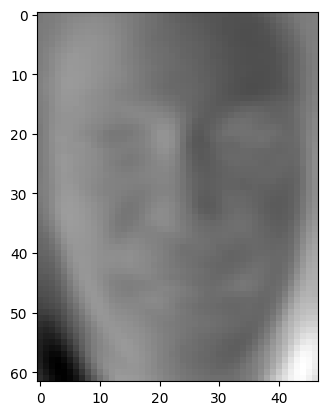

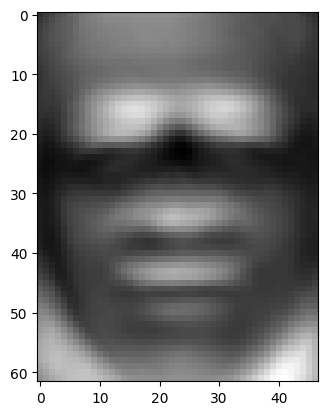

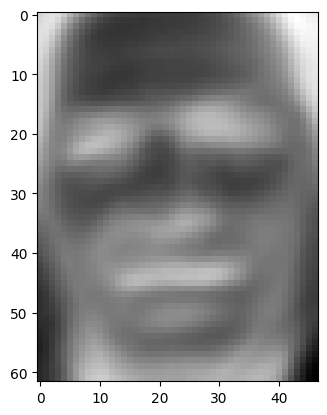

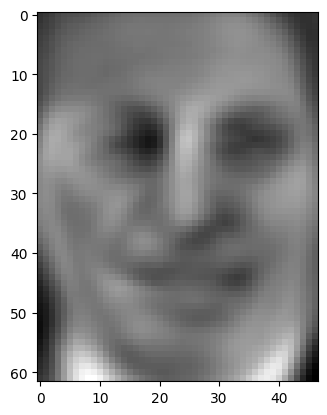

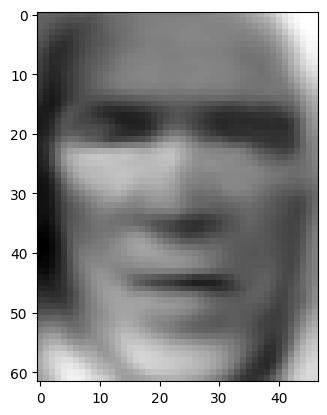

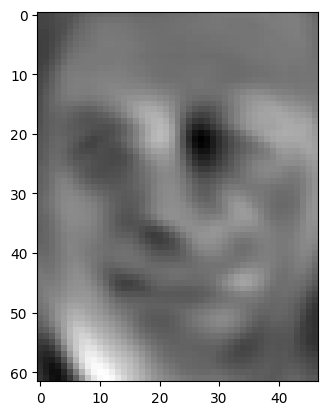

In [7]:
for i in range(10):
    eigenface = eigenfaces[i].reshape((train_x.shape[1], train_x.shape[2]))
    plt.figure()
    plt.imshow(eigenface, cmap="gray")

Spooky!

Now, let's use the Eigenfaces to extract facial features from the training and test set vectors. Since we have `173` Eigenfaces, we will reduce the dimensionality of the `2914`-dimensional train/test vectors to `173`-dimensional train/test feature vectors.

In [8]:
train_features_x = np.dot(train_vector_x, eigenfaces.T)
test_features_x = np.dot(test_vector_x, eigenfaces.T)

print("Training vectors shape: {}".format(train_vector_x.shape))
print("Training features shape: {}".format(train_features_x.shape))
print("Testing vectors shape: {}".format(test_vector_x.shape))
print("Testing features shape: {}".format(test_features_x.shape))

Training vectors shape: (2720, 2914)
Training features shape: (2720, 202)
Testing vectors shape: (303, 2914)
Testing features shape: (303, 202)


Great! Now that we have extracted facial features from the train and testing set, let's perform facial identification using a simple logistic regression model!

In [9]:
# specify the input size of the feature vectors
features = Input((train_features_x.shape[1],))
# a single fully-connected layer to map the features to a logit vector with one logit per subject
x = Dense(num_subjects)(features)
# use softmax activation to convert the logits to class probabilities for each subject
predictions = Activation("softmax")(x)

# create the model using the layers we defined previously
logistic_regression = Model(inputs=features, outputs=predictions)

# compile the model so that it uses Adam for optimization during training with cross-entropy loss
logistic_regression.compile(optimizer=Adam(), loss="sparse_categorical_crossentropy", metrics=["acc"])

# print out a summary of the model achitecture
print(logistic_regression.summary())

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 202)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 62)             │        12,586 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 62)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,586 (49.16 KB)

 Trainable params: 12,586 (49.16 KB)

 Non-trainable params: 0 (0.00 B)

None


In [10]:
# since the subjects have different numbers of images, 
# we need to balance how much each subject contributes to the cross-entropy loss
class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(train_y), y=train_y)

class_weights = dict(zip(np.unique(train_y), class_weights))   

# train model, verbose set to 0 to supress output, wait a moment for training to complete
logistic_regression.fit(train_features_x, train_y, validation_data=(test_features_x, test_y), 
                        class_weight=class_weights, 
                        epochs=75, batch_size=128, verbose=0)

# evaluate model, get train/test accuracy
train_eig_pred = np.argmax(logistic_regression.predict(train_features_x), axis=1)
test_eig_pred = np.argmax(logistic_regression.predict(test_features_x), axis=1)
print("\nTraining accuracy using Eigenfaces and logistic regression model: {}".format(accuracy_score(train_y, train_eig_pred)))
print("Testing accuracy using Eigenfaces and logistic regression model: {}".format(accuracy_score(test_y, test_eig_pred)))

85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

Training accuracy using Eigenfaces and logistic regression model: 0.05220588235294118
Testing accuracy using Eigenfaces and logistic regression model: 0.033003300330033


# Your turn!

### Sample CNN Model
The Eigenfaces and logistic regression model doesn't perform that well on the unseen test set. Let's see how a simple CNN model compares.

Rather than dealing with vectors, we will begin working with the grayscale images directly. 

Remember that a CNN learns convolution filters which extract the most useful features. Then, a small neural network at the end of the CNN architecture performs the multi-class classification. Therefore, the CNN will make things less complex for us as the CNN will learn to perform both feature extraction and classification! 

<b> Complete the section below</b>

In [11]:
# COMPLETE THE CODE ACCORDING TO THE COMMENTS

# specify the input size of the images
images = Input((train_x.shape[1], train_x.shape[2], 1,))
# a convolution layer of 32 filters of size 9x9 to extract features (valid padding)
x = Conv2D(32, (9, 9), padding="valid")(images)
# a maxpooling layer to down-sample features with pool size (2, 2)
x = MaxPool2D((2, 2))(x)
# another convolution layer of 64 filters of size 11x11 to extract features (valid padding)
x = Conv2D(64, (11, 11), padding="valid")(x)
# a maxpooling layer to down-sample features with pool size (2, 2)
x = MaxPool2D((2, 2))(x)
# flatten extracted features to form feature vector
x = Flatten()(x)
# a drop out layer for regularization (25% probability)
x = Dropout(0.25)(x)
# first fully-connected layer to map the features to vectors of size 256
x = Dense(256)(x)
# anoter drop out layer for regularization (25% probability)
x = Dropout(0.25)(x)
# a second fully-connected layer to map the features to a logit vector with one logit per subject
x = Dense(num_subjects)(x)
# use softmax activation to convert the logits to class probabilities for each subject
predictions = Activation("softmax")(x)

# create the model using the layers we defined previously
sample_cnn = Model(inputs=images, outputs=predictions)

# compile the model so that it uses Adam for optimization during training with cross-entropy loss
sample_cnn.compile(optimizer=Adam(), loss="sparse_categorical_crossentropy", metrics=["acc"])

# print out a summary of the model achitecture
print(sample_cnn.summary())

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 62, 47, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 54, 39, 32)     │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 27, 19, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 17, 9, 64)      │       247,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 62)             │        15,934 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 62)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 790,974 (3.02 MB)

 Trainable params: 790,974 (3.02 MB)

 Non-trainable params: 0 (0.00 B)

None


In [12]:
# since the subjects have different numbers of images, 
# we need to balance how much each subject contributes to the cross-entropy loss
class_weights = compute_class_weight(class_weight= "balanced", classes= np.unique(train_y), y = train_y)

class_weights = dict(zip(np.unique(train_y), class_weights))

# train model
sample_cnn.fit(train_x, train_y, validation_data=(test_x, test_y), 
               class_weight=class_weights, 
               epochs=15, batch_size=64, verbose=1)

# evaluate model, get train/test accuracy
train_pred = np.argmax(sample_cnn.predict(train_x), axis=1)
test_pred = np.argmax(sample_cnn.predict(test_x), axis=1)


print("\nTraining accuracy using sample CNN model: {}".format(accuracy_score(train_y, train_pred)))
print("Testing accuracy using sample CNN model: {}\n".format(accuracy_score(test_y, test_pred)))


Epoch 1/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - acc: 0.0101 - loss: 4.1561 - val_acc: 0.0099 - val_loss: 4.1436
Epoch 2/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step - acc: 0.0079 - loss: 4.1530 - val_acc: 0.0066 - val_loss: 4.2276
Epoch 3/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 117ms/step - acc: 0.0147 - loss: 4.1647 - val_acc: 0.0165 - val_loss: 4.1546
Epoch 4/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - acc: 0.0180 - loss: 4.1359 - val_acc: 0.0198 - val_loss: 4.2461
Epoch 5/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 7s 154ms/step - acc: 0.0279 - loss: 4.0606 - val_acc: 0.0231 - val_loss: 4.0314
Epoch 6/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 144ms/step - acc: 0.0379 - loss: 3.9744 - val_acc: 0.0264 - val_loss: 3.9457
Epoch 7/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 140ms/step - acc: 0.0569 - loss: 3.7742 - val_acc: 0.0594 - val_loss: 3.7239
Epoch 8/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 114ms/step - acc: 0.0835 - loss: 3.5487 - val_acc: 0.0627 - val_loss: 3.5946
Epoch 9/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 112ms/step - acc

In [13]:
print("The sample CNN model beat the Eigenfaces and logistic regression model! :)")
print("\nTraining accuracy using sample CNN model: {}".format(accuracy_score(train_y, train_pred)))
print("Testing accuracy using sample CNN model: {}\n".format(accuracy_score(test_y, test_pred)))
print("Training accuracy using Eigenfaces and logistic regression model: {}".format(accuracy_score(train_y, train_eig_pred)))
print("Testing accuracy using Eigenfaces and logistic regression model: {}".format(accuracy_score(test_y, test_eig_pred)))

The sample CNN model beat the Eigenfaces and logistic regression model! :)

Training accuracy using sample CNN model: 0.3599264705882353
Testing accuracy using sample CNN model: 0.2508250825082508

Training accuracy using Eigenfaces and logistic regression model: 0.05220588235294118
Testing accuracy using Eigenfaces and logistic regression model: 0.033003300330033


## More tasks

2. Build three CNN models which surpass the traditional Eigenface method test accuracy. In each model use different architectures and optimizers. Points will be not be awarded if models architectures are not sufficiently different 
3. Build a fourth CNN model which achieves >70% test accuracy 
4. Display a correctly identified image and a training image corresponding to the correct training subject 
5. Display a incorrectly identified image and a training image corresponding to the correct training subject 

### Rubric

1. Complete the sample CNN as specified by the comments (2 pts.)
2. Build three CNN models which surpass the traditional Eigenface method test accuracy. In each model use different architectures and optimizers. Points will be not be awarded if models architectures are not sufficiently different (3 pts.)
3. Build a fourth CNN model which achieves >70% test accuracy (3 pts.)
4. Display a correctly identified image and a training image corresponding to the correct training subject (1 pts.)
5. Display a incorrectly identified image and a training image corresponding to the correct training subject (1 pts.)

Feel free to use the code above to get started on your own models!

## Model 1: Wider Kernel and shallow Model with Adam Optimizer - Batch Normalization and Dropout

In [ ]:
images = Input((train_x.shape[1], train_x.shape[2], 1,))
# a convolution layer of 32 filters of size 3x3 with padding to maintain spatial dimensions
x = Conv2D(32, (13, 13), padding="same")(images)
x = BatchNormalization()(x)
x = MaxPool2D((2, 2))(x)

# another convolution layer of 64 filters of size 3x3 with padding
x = Conv2D(64, (13, 13), padding="same")(x)
x = BatchNormalization()(x)
x = MaxPool2D((2, 2))(x)

# flatten extracted features to form feature vector
x = Flatten()(x)
# a drop out layer for regularization (25% probability)
x = Dropout(0.5)(x)
# first fully-connected layer to map the features to vectors of size 256
x = Dense(256)(x)
# anoter drop out layer for regularization (25% probability)
x = Dropout(0.5)(x)
# a second fully-connected layer to map the features to a logit vector with one logit per subject
x = Dense(num_subjects)(x)
# use softmax activation to convert the logits to class probabilities for each subject
predictions = Activation("softmax")(x)

model1 = Model(inputs=images, outputs=predictions)
model1.compile(optimizer=Adam(learning_rate=0.00005),
               loss="sparse_categorical_crossentropy", metrics=["acc"])

print(model1.summary())

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 62, 47, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 62, 47, 32)     │         5,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 62, 47, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 31, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 31, 23, 64)     │       346,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 31, 23, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 15, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 10560)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 10560)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │     2,703,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 62)             │        15,934 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 62)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,071,550 (11.72 MB)

 Trainable params: 3,071,358 (11.72 MB)

 Non-trainable params: 192 (768.00 B)

None


In [15]:
class_weights = compute_class_weight(class_weight= "balanced", classes= np.unique(train_y), y = train_y)

class_weights = dict(zip(np.unique(train_y), class_weights))

# train model
model1.fit(train_x, train_y, validation_data=(test_x, test_y), 
               class_weight=class_weights, 
               epochs=15, batch_size=64, verbose=1)

# evaluate model, get train/test accuracy
model1_train_pred = np.argmax(model1.predict(train_x), axis=1)
model1_test_pred = np.argmax(model1.predict(test_x), axis=1)


print("\nTraining accuracy using model1: {}".format(accuracy_score(train_y, model1_train_pred)))
print("Testing accuracy using model1: {}\n".format(accuracy_score(test_y, model1_test_pred)))

Epoch 1/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 22s 454ms/step - acc: 0.0187 - loss: 4.2483 - val_acc: 0.0264 - val_loss: 4.1265
Epoch 2/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 20s 465ms/step - acc: 0.0547 - loss: 3.9130 - val_acc: 0.0429 - val_loss: 4.1252
Epoch 3/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 21s 479ms/step - acc: 0.0873 - loss: 3.7106 - val_acc: 0.0363 - val_loss: 4.1238
Epoch 4/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 20s 452ms/step - acc: 0.1106 - loss: 3.4837 - val_acc: 0.0363 - val_loss: 4.1213
Epoch 5/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 19s 448ms/step - acc: 0.1673 - loss: 3.2306 - val_acc: 0.0462 - val_loss: 4.1162
Epoch 6/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 22s 507ms/step - acc: 0.1875 - loss: 3.0069 - val_acc: 0.0594 - val_loss: 4.1074
Epoch 7/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 22s 504ms/step - acc: 0.2310 - loss: 2.7761 - val_acc: 0.0660 - val_loss: 4.0898
Epoch 8/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 19s 448ms/step - acc: 0.2706 - loss: 2.5970 - val_acc: 0.1320 - val_loss: 4.0635
Epoch 9/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 20s 465ms/

## Model 2 – Deeper Architecture with Mixed Kernels and w/o Batch Normalization using RMS Prop Optimizer

In [16]:
images = Input((train_x.shape[1], train_x.shape[2], 1,))
# a convolution layer of 32 filters of size 3x3 with padding to maintain spatial dimensions
x = Conv2D(32, (7, 7), padding="same")(images)
x = MaxPool2D((2, 2))(x)

# another convolution layer of 64 filters of size 3x3 with padding
x = Conv2D(64, (5, 5), padding="same")(x)
x = MaxPool2D((2, 2))(x)

# another convolution layer of 64 filters of size 3x3 with padding
x = Conv2D(64, (5, 5), padding="same")(x)
x = MaxPool2D((2, 2))(x)

# flatten extracted features to form feature vector
x = Flatten()(x)
# a drop out layer for regularization (25% probability)
x = Dropout(0.25)(x)
# first fully-connected layer to map the features to vectors of size 256
x = Dense(256)(x)
# anoter drop out layer for regularization (25% probability)
x = Dropout(0.25)(x)
# a second fully-connected layer to map the features to a logit vector with one logit per subject
x = Dense(num_subjects)(x)
# use softmax activation to convert the logits to class probabilities for each subject
predictions = Activation("softmax")(x)

model2 = Model(inputs=images, outputs=predictions)
model2.compile(optimizer=RMSprop(),
               loss="sparse_categorical_crossentropy", metrics=["acc"])

print(model2.summary())

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 62, 47, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 62, 47, 32)     │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 31, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 31, 23, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 15, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 15, 11, 64)     │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 7, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2240)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 2240)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       573,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 62)             │        15,934 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 62)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 744,958 (2.84 MB)

 Trainable params: 744,958 (2.84 MB)

 Non-trainable params: 0 (0.00 B)

None


In [17]:

class_weights = compute_class_weight(class_weight= "balanced", classes= np.unique(train_y), y = train_y)

class_weights = dict(zip(np.unique(train_y), class_weights))

# train model
model2.fit(train_x, train_y, validation_data=(test_x, test_y), 
               class_weight=class_weights, 
               epochs=15, batch_size=64, verbose=1)

# evaluate model, get train/test accuracy
model2_train_pred = np.argmax(model2.predict(train_x), axis=1)
model2_test_pred = np.argmax(model2.predict(test_x), axis=1)


print("\nTraining accuracy using model2: {}".format(accuracy_score(train_y, model2_train_pred)))
print("Testing accuracy using model2: {}\n".format(accuracy_score(test_y, model2_test_pred)))

Epoch 1/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 7s 126ms/step - acc: 0.0108 - loss: 4.1599 - val_acc: 0.0099 - val_loss: 4.1179
Epoch 2/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 123ms/step - acc: 0.0121 - loss: 4.1534 - val_acc: 0.0099 - val_loss: 4.1221
Epoch 3/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 123ms/step - acc: 0.0098 - loss: 4.1578 - val_acc: 0.0099 - val_loss: 4.1270
Epoch 4/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 123ms/step - acc: 0.0107 - loss: 4.1527 - val_acc: 0.0099 - val_loss: 4.3700
Epoch 5/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 121ms/step - acc: 0.0090 - loss: 4.1848 - val_acc: 0.0099 - val_loss: 4.2891
Epoch 6/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 124ms/step - acc: 0.0094 - loss: 4.1635 - val_acc: 0.0099 - val_loss: 4.1378
Epoch 7/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 129ms/step - acc: 0.0118 - loss: 4.1485 - val_acc: 0.0099 - val_loss: 4.3055
Epoch 8/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 125ms/step - acc: 0.0178 - loss: 4.1421 - val_acc: 0.0099 - val_loss: 4.1149
Epoch 9/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 122ms/step - ac

## Model 3 – Wide shallow network with two convolution layers and mixed Kernels with SGD Optimizer and small batch size

In [84]:
images = Input((train_x.shape[1], train_x.shape[2], 1,))

# First convolutional branch
x1 = Conv2D(32, (3, 3), padding="same")(images)
x1 = MaxPool2D((2, 2))(x1)
x1 = Conv2D(64, (3, 3), padding="same")(x1)
x1 = MaxPool2D((2, 2))(x1)

# Second convolutional branch
x2 = Conv2D(32, (5, 5), padding="same")(images)
x2 = MaxPool2D((2, 2))(x2)
x2 = Conv2D(64, (5, 5), padding="same")(x2)
x2 = MaxPool2D((2, 2))(x2)


# Concatenate the two branches
x = Concatenate()([x1, x2])

# Flatten the concatenated output
x = Flatten()(x)

# Fully connected layers
x = Dense(512)(x)
x = Dense(256)(x)

# Output layer
predictions = Dense(num_subjects, activation="softmax")(x)

# Create the model
model3 = Model(inputs=images, outputs=predictions)

# Compile the model
model3.compile(optimizer=SGD(learning_rate=0.0005, momentum=0.9),
               loss="sparse_categorical_crossentropy", metrics=["acc"])

# Print the model summary
print(model3.summary())

Model: "functional_38"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_39      │ (None, 62, 47, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_162 (Conv2D) │ (None, 62, 47,    │        320 │ input_layer_39[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_164 (Conv2D) │ (None, 62, 47,    │        832 │ input_layer_39[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_162   │ (None, 31, 23,    │          0 │ conv2d_162[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_164   │ (None, 31, 23,    │          0 │ conv2d_164[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_163 (Conv2D) │ (None, 31, 23,    │     18,496 │ max_pooling2d_16… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_165 (Conv2D) │ (None, 31, 23,    │     51,264 │ max_pooling2d_16… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_163   │ (None, 15, 11,    │          0 │ conv2d_163[0][0]  │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_165   │ (None, 15, 11,    │          0 │ conv2d_165[0][0]  │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_30      │ (None, 15, 11,    │          0 │ max_pooling2d_16… │
│ (Concatenate)       │ 128)              │            │ max_pooling2d_16… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_37          │ (None, 21120)     │          0 │ concatenate_30[0… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_78 (Dense)    │ (None, 512)       │ 10,813,952 │ flatten_37[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_79 (Dense)    │ (None, 256)       │    131,328 │ dense_78[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_80 (Dense)    │ (None, 62)        │     15,934 │ dense_79[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 11,032,126 (42.08 MB)

 Trainable params: 11,032,126 (42.08 MB)

 Non-trainable params: 0 (0.00 B)

None


In [82]:

class_weights = compute_class_weight(class_weight= "balanced", classes= np.unique(train_y), y = train_y)

class_weights = dict(zip(np.unique(train_y), class_weights))

# train model
model3.fit(train_x, train_y, validation_data=(test_x, test_y), 
               class_weight=class_weights, 
               epochs=15, batch_size=8, verbose=1)

# evaluate model, get train/test accuracy
model3_train_pred = np.argmax( model3.predict(train_x), axis=1)
model3_test_pred = np.argmax(model3.predict(test_x), axis=1)


print("\nTraining accuracy using model3: {}".format(accuracy_score(train_y, model3_train_pred)))
print("Testing accuracy using model3: {}\n".format(accuracy_score(test_y, model3_test_pred)))

Epoch 1/15
340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - acc: 0.0083 - loss: 4.1891 - val_acc: 0.0033 - val_loss: 4.1037
Epoch 2/15
340/340 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - acc: 0.0177 - loss: 4.1959 - val_acc: 0.0033 - val_loss: 4.2060
Epoch 3/15
340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - acc: 0.0136 - loss: 4.1936 - val_acc: 0.0066 - val_loss: 4.1448
Epoch 4/15
340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - acc: 0.0292 - loss: 4.0968 - val_acc: 0.0825 - val_loss: 3.6550
Epoch 5/15
340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - acc: 0.1619 - loss: 3.3457 - val_acc: 0.2178 - val_loss: 3.1540
Epoch 6/15
340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - acc: 0.3019 - loss: 2.7090 - val_acc: 0.3366 - val_loss: 2.9216
Epoch 7/15
340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - acc: 0.4218 - loss: 2.2417 - val_acc: 0.4719 - val_loss: 2.4357
Epoch 8/15
340/340 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - acc: 0.5090 - loss: 1.8506 - val_acc: 0.5017 - val_loss: 2.4068
Epoch 9/15
340/340 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/

## Model 4

In [120]:
images = Input((train_x.shape[1], train_x.shape[2], 1,))
# a convolution layer of 32 filters of size 3x3 with padding to maintain spatial dimensions
x = Conv2D(32, (5, 5), padding="same")(images)
x = MaxPool2D((2, 2))(x)

# another convolution layer of 64 filters of size 3x3 with padding
x = Conv2D(64, (7, 7), padding="same")(x)
x = MaxPool2D((2, 2))(x)

x = Conv2D(64, (9, 9), padding="same")(x)
x = BatchNormalization()(x)
x = MaxPool2D((2, 2))(x)

# flatten extracted features to form feature vector
x = Flatten()(x)
# a drop out layer for regularization (25% probability)
x = Dropout(0.5)(x)
# first fully-connected layer to map the features to vectors of size 256
x = Dense(256)(x)
# anoter drop out layer for regularization (25% probability)
x = Dropout(0.5)(x)
# a second fully-connected layer to map the features to a logit vector with one logit per subject
x = Dense(num_subjects)(x)
# use softmax activation to convert the logits to class probabilities for each subject
predictions = Activation("softmax")(x)

model4 = Model(inputs=images, outputs=predictions)
model4.compile(optimizer=Adam(learning_rate=0.00005),
               loss="sparse_categorical_crossentropy", metrics=["acc"])

print(model4.summary())

Model: "functional_53"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_53 (InputLayer)     │ (None, 62, 47, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_209 (Conv2D)             │ (None, 62, 47, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_203               │ (None, 31, 23, 32)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_210 (Conv2D)             │ (None, 31, 23, 64)     │       100,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_204               │ (None, 15, 11, 64)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_211 (Conv2D)             │ (None, 15, 11, 64)     │       331,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 15, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_205               │ (None, 7, 5, 64)       │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_51 (Flatten)            │ (None, 2240)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_73 (Dropout)            │ (None, 2240)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_107 (Dense)               │ (None, 256)            │       573,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_74 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_108 (Dense)               │ (None, 7)              │         1,799 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_45 (Activation)      │ (None, 7)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,008,839 (3.85 MB)

 Trainable params: 1,008,711 (3.85 MB)

 Non-trainable params: 128 (512.00 B)

None


In [123]:

class_weights = compute_class_weight(class_weight= "balanced", classes= np.unique(train_y), y = train_y)

class_weights = dict(zip(np.unique(train_y), class_weights))

# train model
model4.fit(train_x, train_y, validation_data=(test_x, test_y), 
               class_weight=class_weights, 
               epochs=20, batch_size=64, verbose=1)

# evaluate model, get train/test accuracy
model4_train_pred = np.argmax( model4.predict(train_x), axis=1)
model4_test_pred = np.argmax(model4.predict(test_x), axis=1)


print("\nTraining accuracy using model4: {}".format(accuracy_score(train_y, model4_train_pred)))
print("Testing accuracy using model4: {}\n".format(accuracy_score(test_y, model4_test_pred)))

Epoch 1/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 120ms/step - acc: 0.7084 - loss: 0.8700 - val_acc: 0.7597 - val_loss: 0.8321
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 238ms/step - acc: 0.7120 - loss: 0.8316 - val_acc: 0.7674 - val_loss: 0.8113
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 224ms/step - acc: 0.7189 - loss: 0.8463 - val_acc: 0.7597 - val_loss: 0.8375
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 249ms/step - acc: 0.7074 - loss: 0.8074 - val_acc: 0.7674 - val_loss: 0.7773
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 277ms/step - acc: 0.7269 - loss: 0.8094 - val_acc: 0.7597 - val_loss: 0.7649
Epoch 6/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 275ms/step - acc: 0.7037 - loss: 0.7907 - val_acc: 0.7752 - val_loss: 0.7274
Epoch 7/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 259ms/step - acc: 0.7412 - loss: 0.7470 - val_acc: 0.7442 - val_loss: 0.7987
Epoch 8/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 263ms/step - acc: 0.7316 - loss: 0.7508 - val_acc: 0.7829 - val_loss: 0.7182
Epoch 9/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 264ms/step - ac

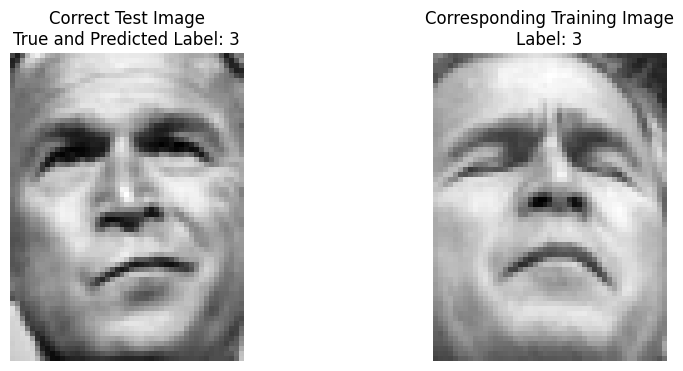

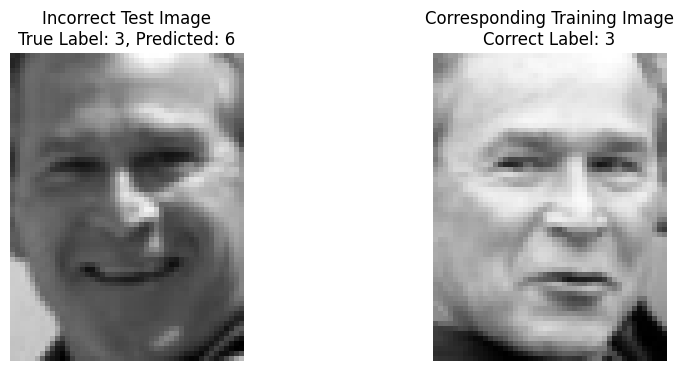

In [127]:
# Find indices of correctly and incorrectly identified images
correct_indices = np.where(test_y == model4_test_pred)[0]
incorrect_indices = np.where(test_y != model4_test_pred)[0]

if len(correct_indices) > 0 and len(incorrect_indices) > 0:
    # Get a random correct prediction
    correct_idx = np.random.choice(correct_indices)
    
    # Get a random incorrect prediction
    incorrect_idx = np.random.choice(incorrect_indices)
    
    # Get corresponding true labels
    correct_label = test_y[correct_idx]
    incorrect_label = test_y[incorrect_idx]
    
    # Find training images with the same labels
    correct_train_idx = np.random.choice(np.where(train_y == correct_label)[0])
    incorrect_train_idx = np.random.choice(np.where(train_y == incorrect_label)[0])
    
    # Plot correctly identified pair
    plt.figure(figsize=(10, 4))
    plt.subplot(121)
    plt.imshow(test_x[correct_idx, :, :, 0], cmap='gray')
    plt.title(f'Correct Test Image\nTrue and Predicted Label: {correct_label}')
    plt.axis('off')
    
    plt.subplot(122)
    plt.imshow(train_x[correct_train_idx, :, :, 0], cmap='gray')
    plt.title(f'Corresponding Training Image\nLabel: {correct_label}')
    plt.axis('off')
    plt.show()
    
    # Plot incorrectly identified pair
    plt.figure(figsize=(10, 4))
    plt.subplot(121)
    plt.imshow(test_x[incorrect_idx, :, :, 0], cmap='gray')
    plt.title(f'Incorrect Test Image\nTrue Label: {incorrect_label}, Predicted: {model4_test_pred[incorrect_idx]}')
    plt.axis('off')
    
    plt.subplot(122)
    plt.imshow(train_x[incorrect_train_idx, :, :, 0], cmap='gray')
    plt.title(f'Corresponding Training Image\nCorrect Label: {incorrect_label}')
    plt.axis('off')
    plt.show()

Assignment was done in a study group with Vigneshwar Ravi Rao